In [1]:
import json 
import numpy as np
import matplotlib.pyplot as plt
import torch

In [2]:
# Load frame from json file
with open('frame_sample.json', 'r') as f:
    frame = json.load(f)
    frame = np.array(frame, dtype=np.uint8)
    frame = frame.reshape((210, 160, 3))

In [3]:
frame.shape

(210, 160, 3)

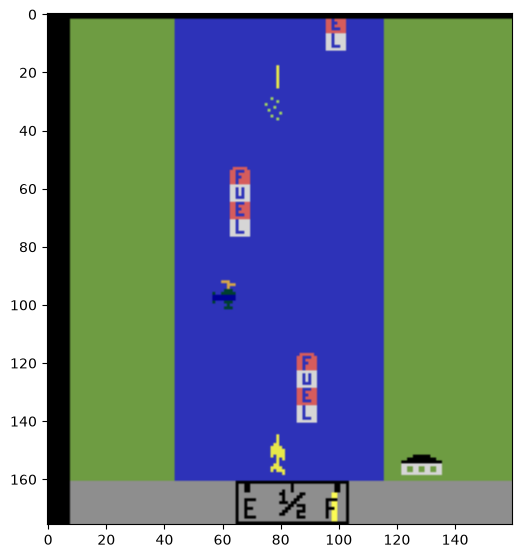

In [5]:
frame_modiffied = np.concat((frame[:161, :, :], frame[175:190, :, :]), axis=0)
# Visualize frame
plt.figure(figsize=(6, 8))
plt.imshow(frame_modiffied)
plt.show()

In [6]:
print("Raw frame shape:", frame_modiffied.shape)

Raw frame shape: (176, 160, 3)


In [3]:
torch.cuda.is_available()

False

In [3]:
import torch.nn.functional as F

In [4]:
a = torch.tensor([[3, 4], [6, 8]], dtype=torch.float32)
distances = torch.norm(a - torch.tensor([0., 0.], ), dim=1)
distances

tensor([ 5., 10.])

In [2]:
import scipy.signal as signal

def discount(x, gamma):
  """
  Compute discounted sum of future values
  out[i] = in[i] + gamma * in[i+1] + gamma^2 * in[i+2] + ...
  """
  return signal.lfilter([1], [1, -gamma], x[::-1], axis=0)[::-1]

In [3]:
discount(np.array([1, 2, 3, 4]), 0.9)

array([8.146, 7.94 , 6.6  , 4.   ])

In [5]:
2 + 6.6 * 0.9

7.9399999999999995